Intercepto: 225.42430515816184
Coeficiente de Temperatura: 8.590443205712262
Coeficiente de Velocidade do Vento: -5.517537459813973
Coeficiente de Precipitação: -7.380297389317422


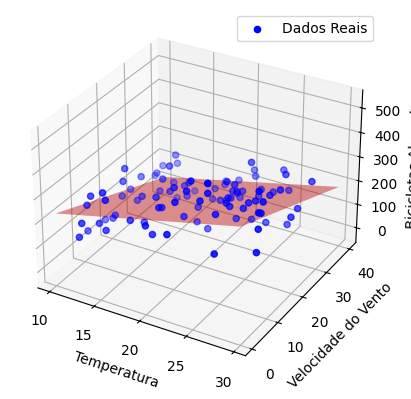

In [2]:
import numpy as np
import pandas as pd
from numpy.linalg import inv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Função para calcular os coeficientes usando o método dos mínimos quadrados
def calcular_coeficientes(X, y):
    # Adiciona uma coluna de 1s para o intercepto
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    # Cálculo dos coeficientes
    theta_best = inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return theta_best

# Carregar os dados
caminho_csv = '../data/4.2 - dados_aluguel_bicicletas.csv'  # Atualize com o caminho correto do arquivo
dados = pd.read_csv(caminho_csv)

# Preparar os dados
X = dados[['Temperatura', 'VelocidadeVento', 'Precipitacao']].values
y = dados['BicicletasAlugadas'].values

# Calcular os coeficientes
coeficientes = calcular_coeficientes(X, y)

# Coeficientes obtidos
intercepto, coef_temperatura, coef_vento, coef_precipitacao = coeficientes

# Imprimir os coeficientes
print(f"Intercepto: {intercepto}")
print(f"Coeficiente de Temperatura: {coef_temperatura}")
print(f"Coeficiente de Velocidade do Vento: {coef_vento}")
print(f"Coeficiente de Precipitação: {coef_precipitacao}")

# Visualização 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotar os dados
ax.scatter(X[:, 0], X[:, 1], y, c='blue', marker='o', label='Dados Reais')

# Criar uma malha de pontos para visualização da superfície de regressão
x_surf, y_surf = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 100), 
                             np.linspace(X[:, 1].min(), X[:, 1].max(), 100))
# Apenas para efeito de visualização, consideraremos a precipitação como a média do conjunto de dados
z = lambda x_surf, y_surf: (coeficientes[0] + 
                            coef_temperatura * x_surf + 
                            coef_vento * y_surf + 
                            coef_precipitacao * np.mean(X[:, 2]))

ax.plot_surface(x_surf, y_surf, z(x_surf, y_surf), color='red', alpha=0.5, rstride=1, cstride=1)

ax.set_xlabel('Temperatura')
ax.set_ylabel('Velocidade do Vento')
ax.set_zlabel('Bicicletas Alugadas')
ax.legend()
plt.show()
